In [1]:
import pandas as pd
import plotly.express as px
import pytz
from datetime import datetime

In [2]:
apps_df = pd.read_csv(r"C:\Users\ashis\OneDrive\Desktop\GooglePlayProject\Play Store Data.csv")

In [3]:
reviews_df = pd.read_csv(r"C:\Users\ashis\OneDrive\Desktop\GooglePlayProject\User Reviews.csv")

In [4]:
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '')
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '')
apps_df = apps_df[apps_df['Installs'] != 'Free']
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'],errors='coerce')
apps_df = apps_df.dropna(subset=['Installs'])

In [5]:
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'],errors='coerce')
apps_df = apps_df.dropna(subset=['Reviews'])

In [6]:
apps_df['Rating'] = pd.to_numeric(apps_df['Rating'],errors='coerce')
apps_df = apps_df.dropna(subset=['Rating'])

In [7]:
apps_df = apps_df[
    apps_df['Size'].str.contains('M', na=False)]
apps_df['Size'] = apps_df['Size'].str.replace('M', '')
apps_df['Size'] = pd.to_numeric(apps_df['Size'],errors='coerce')
apps_df = apps_df.dropna(subset=['Size'])

In [9]:
reviews_df.columns


Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='str')

In [10]:
reviews_df['Sentiment_Subjectivity'] = pd.to_numeric(reviews_df['Sentiment_Subjectivity'],errors='coerce')
reviews_df = reviews_df.dropna(subset=['Sentiment_Subjectivity'])

In [11]:
merged_df = pd.merge(apps_df,reviews_df,on='App',how='inner')

In [12]:
categories=['GAME','BEAUTY','BUSINESS','COMICS','COMMUNICATION','DATING','ENTERTAINMENT','SOCIAL','EVENTS']
merged_df=merged_df[(merged_df['Rating']>3.5)&(merged_df['Category'].isin(categories))&(merged_df['Reviews']>500)&(~merged_df['App'].str.contains('S',na=False))&(merged_df['Sentiment_Subjectivity']>0.5)&(merged_df['Installs']>50000)]

In [13]:
merged_df['Category']=merged_df['Category'].replace({'BEAUTY':'सौंदर्य','BUSINESS':'வணிகம்','DATING':'Dating'})

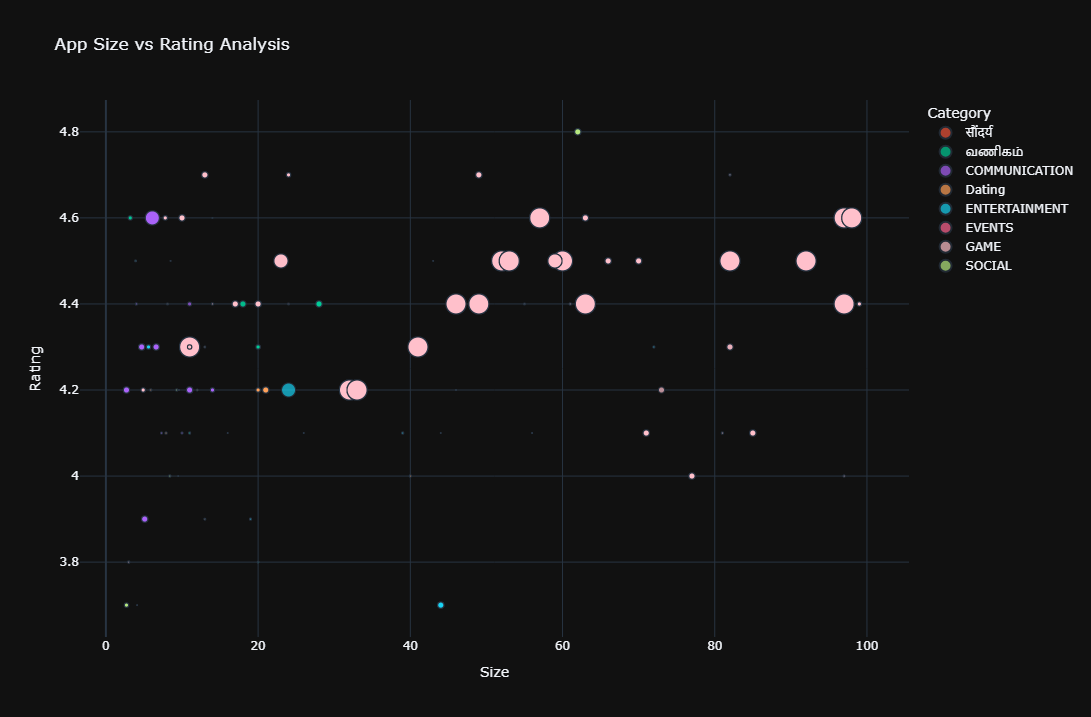

In [14]:
india=pytz.timezone('Asia/Kolkata')
current_time=datetime.now(india)
current_hour=current_time.hour
if 17<=current_hour<19:
    color_map={'GAME':'pink'}
    fig5=px.scatter(
        merged_df,
        x='Size',
        y='Rating',
        size='Installs',
        color='Category',
        hover_name='App',
        title='App Size vs Rating Analysis',
        color_discrete_map=color_map
    )
    fig5.update_layout(
        template='plotly_dark',
        width=1200,
        height=700
    )
    fig5.show()
else:
    print("Graph available only between 5 PM IST and 7 PM IST")